In [12]:
import pandas as pd
import os
import requests

fn = 'NFI_filtered_cleaned.csv'
url_data = 'https://raw.githubusercontent.com/christian-igel/ML/refs/heads/main/data/NFI/' + fn 
if not os.access(fn, os.R_OK):
    print("downloading", url_data)
    try:
        r = requests.get(url_data)
        r.raise_for_status()
        open(fn, 'wb').write(r.content)
    except Exception as e:
        print("download failed:", e)
df = pd.read_csv(fn)
df.to_csv(fn, index=False)


regression_target = "BMag_ha"
classification_target = "C_frac"
features = ['h_mean_1_', 'h_mean_2_', 'h_std_1_', 'h_std_2_', 'h_coov_1_', 'h_coov_2_', 'h_skew_1_', 'h_skew_2_', 
            'IR_', 'h_q5_1_', 'h_q10_1_', 'h_q25_1_', 'h_q50_1_', 'h_q75_1_', 'h_q90_1_', 'h_q95_1_', 
            'h_q99_1_', 'h_q5_2_', 'h_q10_2_', 'h_q25_2_', 'h_q50_2_', 'h_q75_2_', 'h_q90_2_', 'h_q95_2_', 'h_q99_2_', 
            'red_q75', 'red_q50', 'red_q25', 'blue_q75', 'blue_q50', 'blue_q25', 'green_q75', 'green_q50', 'green_q25']


df_trainval = df.query("split in ['train', 'val']")
df_test = df.query("split == 'test'")

X_trainval = df_trainval[features]
y_trainval = df_trainval[[regression_target]]

X_test = df_test[features]
y_test = df_test[[regression_target]]

Number of components that explain 99% of the variance: 14


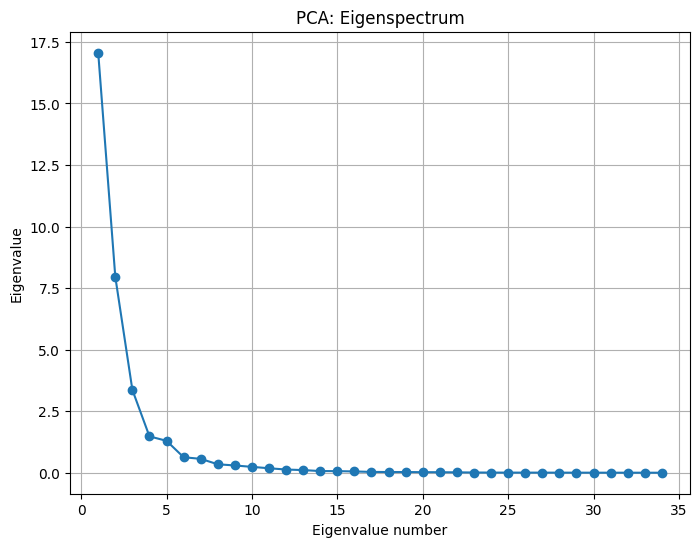

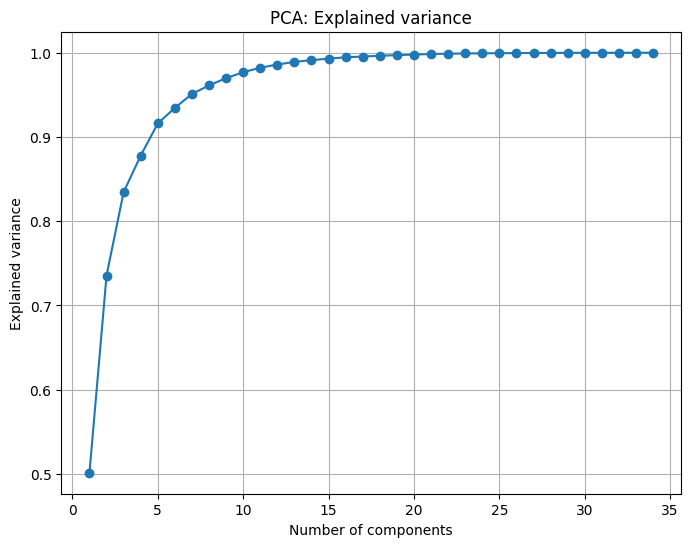

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# standardize features before PCA (whitening -> zero mean + unit variance)
scaler = StandardScaler()
X_trainval_whitened = scaler.fit_transform(X_trainval)

pca = PCA()
X_trainval_pca = pca.fit_transform(X_trainval_whitened)

# N = X_trainval_whitened.shape[0]
# eigenvalues = pca.singular_values_**2 / N
eigenvalues = pca.explained_variance_ # Bessel correction
# print("Eigenvalues:\n", eigenvalues)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
# find number of components to explain 99% of the variance
n_components_99 = np.argmax(explained_variance >= 0.99) + 1
print(f'Number of components that explain 99% of the variance: {n_components_99}')

# Plot the eigenspectrum
plt.figure(figsize=(8, 6))
x = np.arange(1, len(eigenvalues) + 1)
# y = eigenvalues
plt.plot(x, eigenvalues, marker='o')
plt.xlabel('Eigenvalue number')
plt.ylabel('Eigenvalue')
plt.title('PCA: Eigenspectrum')
plt.grid(True)
plt.show()

# Plot the explained variance
plt.figure(figsize=(8, 6))
plt.plot(x, explained_variance, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title('PCA: Explained variance')
plt.grid(True)
plt.show()

In [22]:
# Get loadings for the first principal component
pc1 = pca.components_[1]
print(pc1)

# Find the feature with the largest absolute loading
top_feature_idx = np.argmax(np.abs(pc1))
print(top_feature_idx)
top_feature_name = features[top_feature_idx]

print("Feature most strongly associated with PC1:", top_feature_name)


[ 0.01802074  0.06936455  0.0864513   0.09162603  0.08287714  0.02966626
  0.06650083 -0.04540804 -0.08044339 -0.0226156  -0.03298363 -0.02386084
  0.0063111   0.03650083  0.05452097  0.061168    0.06432709  0.01626256
  0.03311809  0.05613283  0.07207224  0.07831984  0.07813295  0.07665156
  0.07070975  0.31000139  0.32500587  0.32314074  0.30609771  0.31298508
  0.30330177  0.31794213  0.33287546  0.33073655]
32
Feature most strongly associated with PC1: green_q50


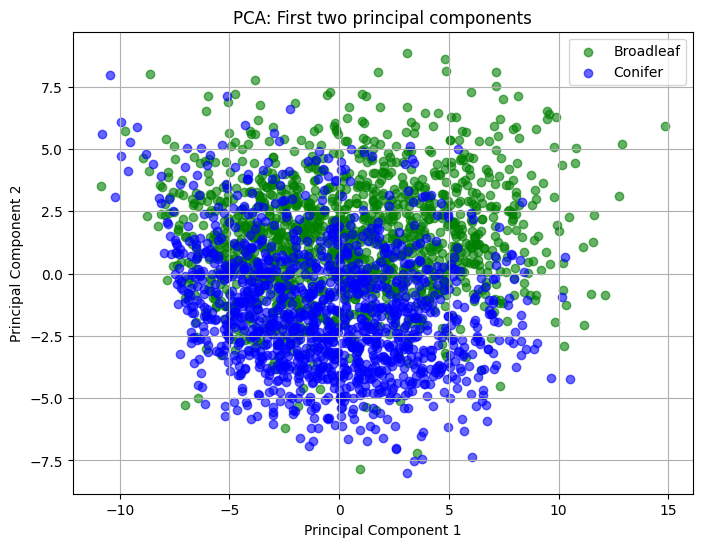

In [18]:
# Visualize the first two principal components
plt.figure(figsize=(8, 6))

# Projecting data onto the first two principal components
X_pca_2d = X_trainval_pca[:, :2]

# Separate data into broadleaf (C_frac == 0) and conifer (C_frac == 1)
broadleaf_mask = df_trainval[classification_target] == 0
conifer_mask = df_trainval[classification_target] == 1

plt.scatter(X_pca_2d[broadleaf_mask, 0], X_pca_2d[broadleaf_mask, 1], 
            color='green', label='Broadleaf', alpha=0.6)
plt.scatter(X_pca_2d[conifer_mask, 0], X_pca_2d[conifer_mask, 1], 
            color='blue', label='Conifer', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First two principal components')
plt.legend()
plt.grid(True)
plt.show()

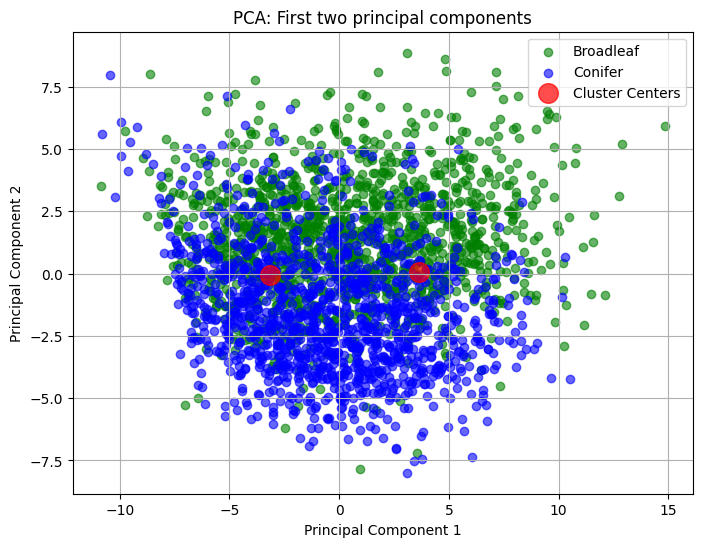

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)
kmeans.fit(X_trainval_pca)
cluster_centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

plt.scatter(X_pca_2d[broadleaf_mask, 0], X_pca_2d[broadleaf_mask, 1], 
            color='green', label='Broadleaf', alpha=0.6)
plt.scatter(X_pca_2d[conifer_mask, 0], X_pca_2d[conifer_mask, 1], 
            color='blue', label='Conifer', alpha=0.6)

plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], color='red', label='Cluster Centers', s=200, alpha=.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First two principal components')
plt.legend()
plt.grid(True)
plt.show()

## Impact of Initialization

In [12]:
# prepare the dataset
data = np.array([
    [0, 1.1],
    [0.1, 1],
    [-0.1, 1],
    [0, 0.9],
    [0, -0.9],
    [0.1, -1],
    [-0.1, -1],
    [0, -1.1],
    [4, 0.05],
    [4, -0.05],
    [4, -0.1],
    [4, 0],
    [3.9, -0.1],
    [4.1, -0.1],
    [4.1, 0.1],
    [4, 0.1],
    [3.9, 0.1]
])

# set initial cluster centers
initial_centers = np.array([
    [0, 1],
    [4, 0.05],
    [4, -0.05]
])

# n_clusters=3 for 3-means
# init=initial_centers to use our chosen initial clusters
# no need to set n_init since init is array-like
kmeans_0 = KMeans(n_clusters=3, init=initial_centers)
kmeans_0.fit(data)

# report the output clusters and their centers
labels = kmeans_0.labels_
centers = kmeans_0.cluster_centers_

print("Cluster labels:", labels, "\n")
print("Cluster centers:", centers)

Cluster labels: [0 0 0 0 0 0 0 0 1 2 2 1 2 2 1 1 1] 

Cluster centers: [[ 0.00000000e+00 -1.63268092e-18]
 [ 4.00000000e+00  7.00000000e-02]
 [ 4.00000000e+00 -8.75000000e-02]]


In [7]:
costs = []
labels = []
centers = []

# set init='random' to avoid using k-mean++
kmeans_1 = KMeans(n_clusters=3, init='random', n_init=1)

for _ in range(20):
    kmeans_1.fit(data)
    # Append the k-means objective function value
    costs.append(kmeans_1.inertia_)
    labels.append(kmeans_1.labels_)
    centers.append(kmeans_1.cluster_centers_)

best_index = costs.index(min(costs))
worst_index = costs.index(max(costs))

print(f"Best k-means cost (lowest inertia): {costs[best_index]}")
print("Cluster labels:", labels[best_index], "\n")
print("Cluster centers:", centers[best_index], "\n")
print(f"Worst k-means cost (highest inertia): {costs[worst_index]}")
print("Cluster labels:", labels[worst_index], "\n")
print("Cluster centers:", centers[worst_index], "\n")


Best k-means cost (lowest inertia): 0.185
Cluster labels: [0 0 0 0 2 2 2 2 1 1 1 1 1 1 1 1 1] 

Cluster centers: [[ 0.00000000e+00  1.00000000e+00]
 [ 4.00000000e+00 -4.71663376e-18]
 [ 0.00000000e+00 -1.00000000e+00]] 

Worst k-means cost (highest inertia): 8.159285714285716
Cluster labels: [2 2 2 2 2 2 2 2 0 0 0 0 0 1 1 0 0] 

Cluster centers: [[ 3.97142857e+00 -1.63268092e-18]
 [ 4.10000000e+00 -1.63268092e-18]
 [ 0.00000000e+00 -1.63268092e-18]] 



In [8]:
costs = []
labels = []
centers = []

kmeans_1 = KMeans(n_clusters=3, n_init=1)

for _ in range(20):
    kmeans_1.fit(data)
    # Append the k-means objective function value
    costs.append(kmeans_1.inertia_)
    labels.append(kmeans_1.labels_)
    centers.append(kmeans_1.cluster_centers_)

best_index = costs.index(min(costs))
worst_index = costs.index(max(costs))

print(f"Best k-means cost (lowest inertia): {costs[best_index]}")
print("Cluster labels:", labels[best_index], "\n")
print("Cluster centers:", centers[best_index], "\n")
print(f"Worst k-means cost (highest inertia): {costs[worst_index]}")
print("Cluster labels:", labels[worst_index], "\n")
print("Cluster centers:", centers[worst_index], "\n")


Best k-means cost (lowest inertia): 0.185
Cluster labels: [2 2 2 2 0 0 0 0 1 1 1 1 1 1 1 1 1] 

Cluster centers: [[ 0.00000000e+00 -1.00000000e+00]
 [ 4.00000000e+00 -4.71663376e-18]
 [ 0.00000000e+00  1.00000000e+00]] 

Worst k-means cost (highest inertia): 0.185
Cluster labels: [2 2 2 2 0 0 0 0 1 1 1 1 1 1 1 1 1] 

Cluster centers: [[ 0.00000000e+00 -1.00000000e+00]
 [ 4.00000000e+00 -4.71663376e-18]
 [ 0.00000000e+00  1.00000000e+00]] 

